In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
input_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\enhanced_frames\match1"
output_folder = r"C:\Users\TECH STORE\OneDrive\Desktop\IP_Project\roi_frames\match1"

os.makedirs(output_folder, exist_ok=True)

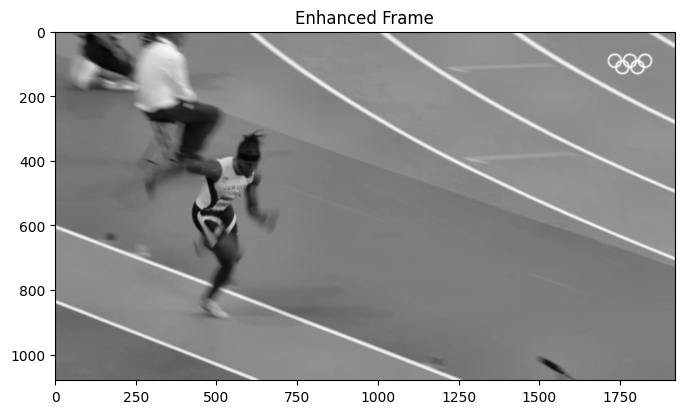

In [3]:
frame_name = "frame_0000.jpg"
image_path = os.path.join(input_folder, frame_name)

img = cv2.imread(image_path, 0)

plt.figure(figsize=(8,6))
plt.imshow(img, cmap="gray")
plt.title("Enhanced Frame")
plt.axis("on")
plt.show()

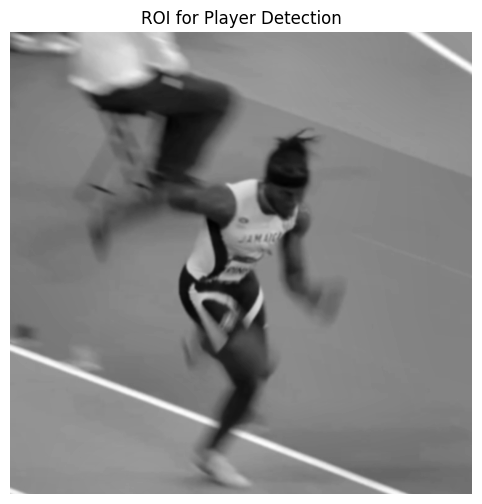

In [4]:
h, w = img.shape

x1, y1 = 150, 150
x2, y2 = 900, 900

roi = img[y1:y2, x1:x2]

plt.figure(figsize=(8,6))
plt.imshow(roi, cmap="gray")
plt.title("ROI for Player Detection")
plt.axis("off")
plt.show()

In [5]:
bg_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=30,
    detectShadows=False
)

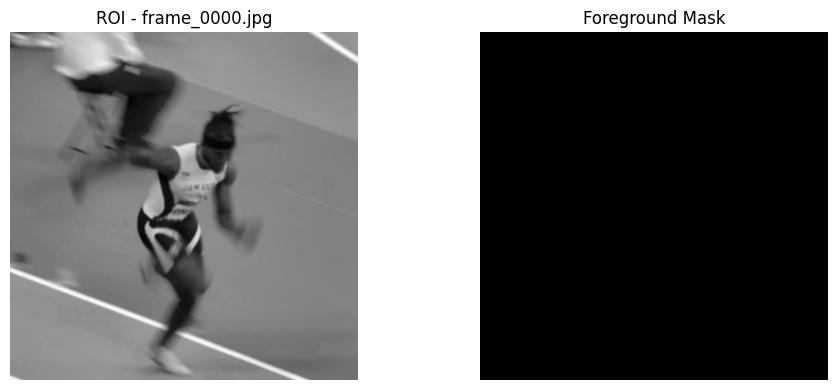

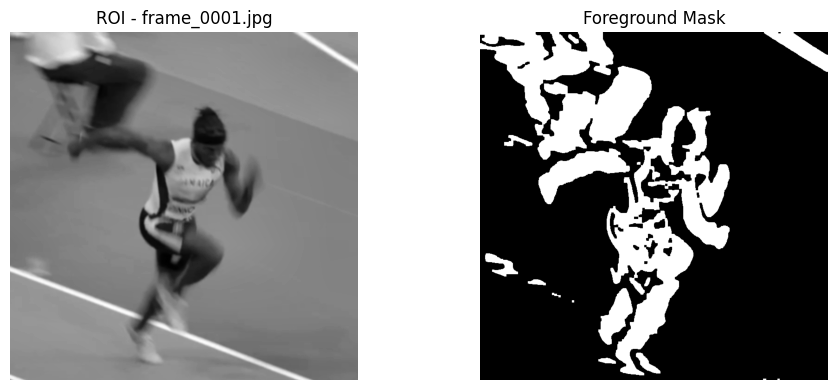

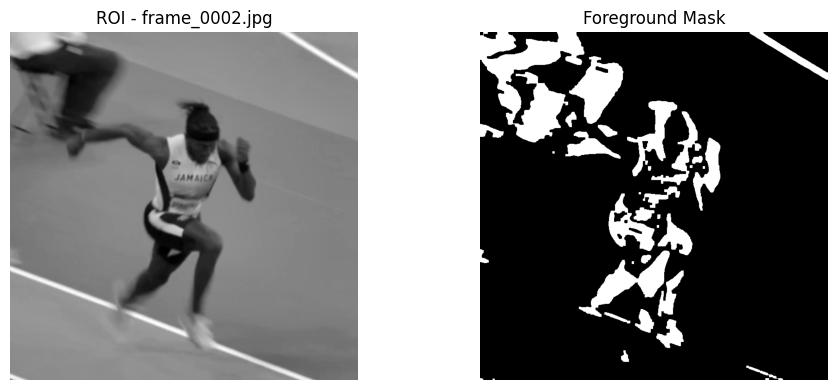

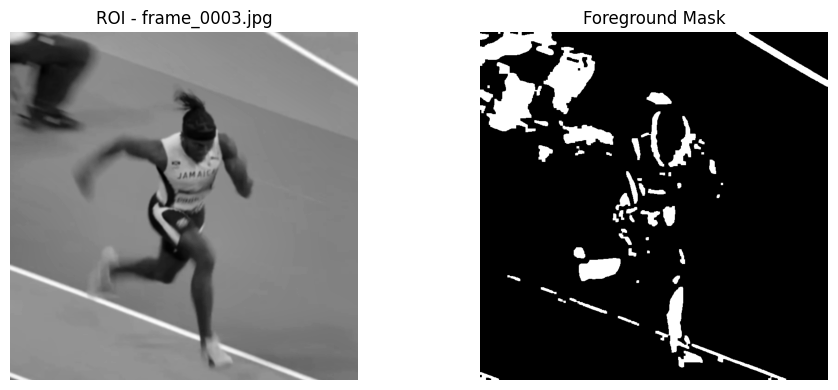

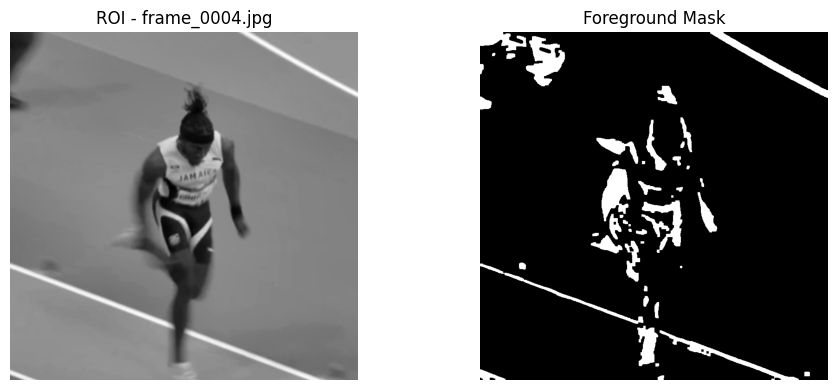

In [6]:
sample_files = ["frame_0000.jpg", "frame_0001.jpg", "frame_0002.jpg", "frame_0003.jpg", "frame_0004.jpg"]

kernel = np.ones((3,3), np.uint8)

for file in sample_files:
    path = os.path.join(input_folder, file)
    img = cv2.imread(path, 0)

    roi = img[y1:y2, x1:x2]

    fg_mask = bg_subtractor.apply(roi)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel, iterations=2)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(roi, cmap="gray")
    plt.title(f"ROI - {file}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(fg_mask, cmap="gray")
    plt.title("Foreground Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
def find_player_contour(mask, prev_center=None):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area < 500 or area > 25000:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        aspect_ratio = h / w if w != 0 else 0

        if aspect_ratio < 1.0 or aspect_ratio > 4.5:
            continue

        cx = x + w // 2
        cy = y + h // 2

        score = area

        if prev_center is not None:
            distance = np.sqrt((cx - prev_center[0])**2 + (cy - prev_center[1])**2)
            score -= distance * 2

        candidates.append((score, cnt, (cx, cy), (x, y, w, h)))

    if len(candidates) == 0:
        return None, None, None

    candidates.sort(key=lambda x: x[0], reverse=True)
    _, best_cnt, best_center, best_box = candidates[0]

    return best_cnt, best_center, best_box

In [8]:
frame_files = sorted(os.listdir(input_folder))
kernel = np.ones((3,3), np.uint8)

prev_center = None

for file in frame_files:
    if file.endswith((".jpg", ".png", ".jpeg")):
        path = os.path.join(input_folder, file)
        img = cv2.imread(path, 0)

        roi = img[y1:y2, x1:x2]

        fg_mask = bg_subtractor.apply(roi)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel, iterations=2)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        best_cnt, best_center, best_box = find_player_contour(fg_mask, prev_center)

        output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        if best_box is not None:
            x, y, w, h = best_box

            x_full = x + x1
            y_full = y + y1

            cv2.rectangle(output, (x_full, y_full), (x_full+w, y_full+h), (255, 255, 255), 2)

            cx_full = best_center[0] + x1
            cy_full = best_center[1] + y1

            cv2.circle(output, (cx_full, cy_full), 4, (255, 255, 255), -1)

            prev_center = best_center

        save_path = os.path.join(output_folder, file)
        cv2.imwrite(save_path, output)

print("ROI-based player detection completed.")

ROI-based player detection completed.


In [9]:
# Segmentation detection consistency calculation

total_frames = len(frame_files)
detected_frames = 0
missing_frames = 0

prev_center = None
kernel = np.ones((3,3), np.uint8)

for file in frame_files:
    if file.endswith((".jpg", ".png", ".jpeg")):
        
        image_path = os.path.join(input_folder, file)
        img = cv2.imread(image_path, 0)
        
        roi = img[y1:y2, x1:x2]
        
        fg_mask = bg_subtractor.apply(roi)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
        
        contour, center, bbox = find_player_contour(fg_mask, prev_center)
        
        if contour is not None:
            detected_frames += 1
            prev_center = center
        else:
            missing_frames += 1

detection_consistency = (detected_frames / total_frames) * 100

print("Segmentation Accuracy / Detection Consistency")
print("Total Frames Tested:", total_frames)
print("Detected Frames:", detected_frames)
print("Missing Frames:", missing_frames)
print("Detection Consistency:", round(detection_consistency, 2), "%")

Segmentation Accuracy / Detection Consistency
Total Frames Tested: 164
Detected Frames: 154
Missing Frames: 10
Detection Consistency: 93.9 %
